In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import get_dataset

In [2]:
df = get_dataset()

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df["Country"].value_counts()

Country
United States    7043
Name: count, dtype: int64

In [7]:
df["State"].value_counts()

State
California    7043
Name: count, dtype: int64

In [8]:
df["City"].unique()

<ArrowStringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str

In [9]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [10]:
df["Contract"].unique()

<ArrowStringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

In [11]:
df.isna().sum()[df.isna().sum() > 0]

Churn Reason    5174
dtype: int64

In [12]:
cols = ["Gender", "Senior Citizen", "Partner", "Dependents", "Phone Service", "Multiple Lines", "Internet Service", "Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies", "Contract", "Paperless Billing", "Payment Method"]

In [13]:
len(cols)

16

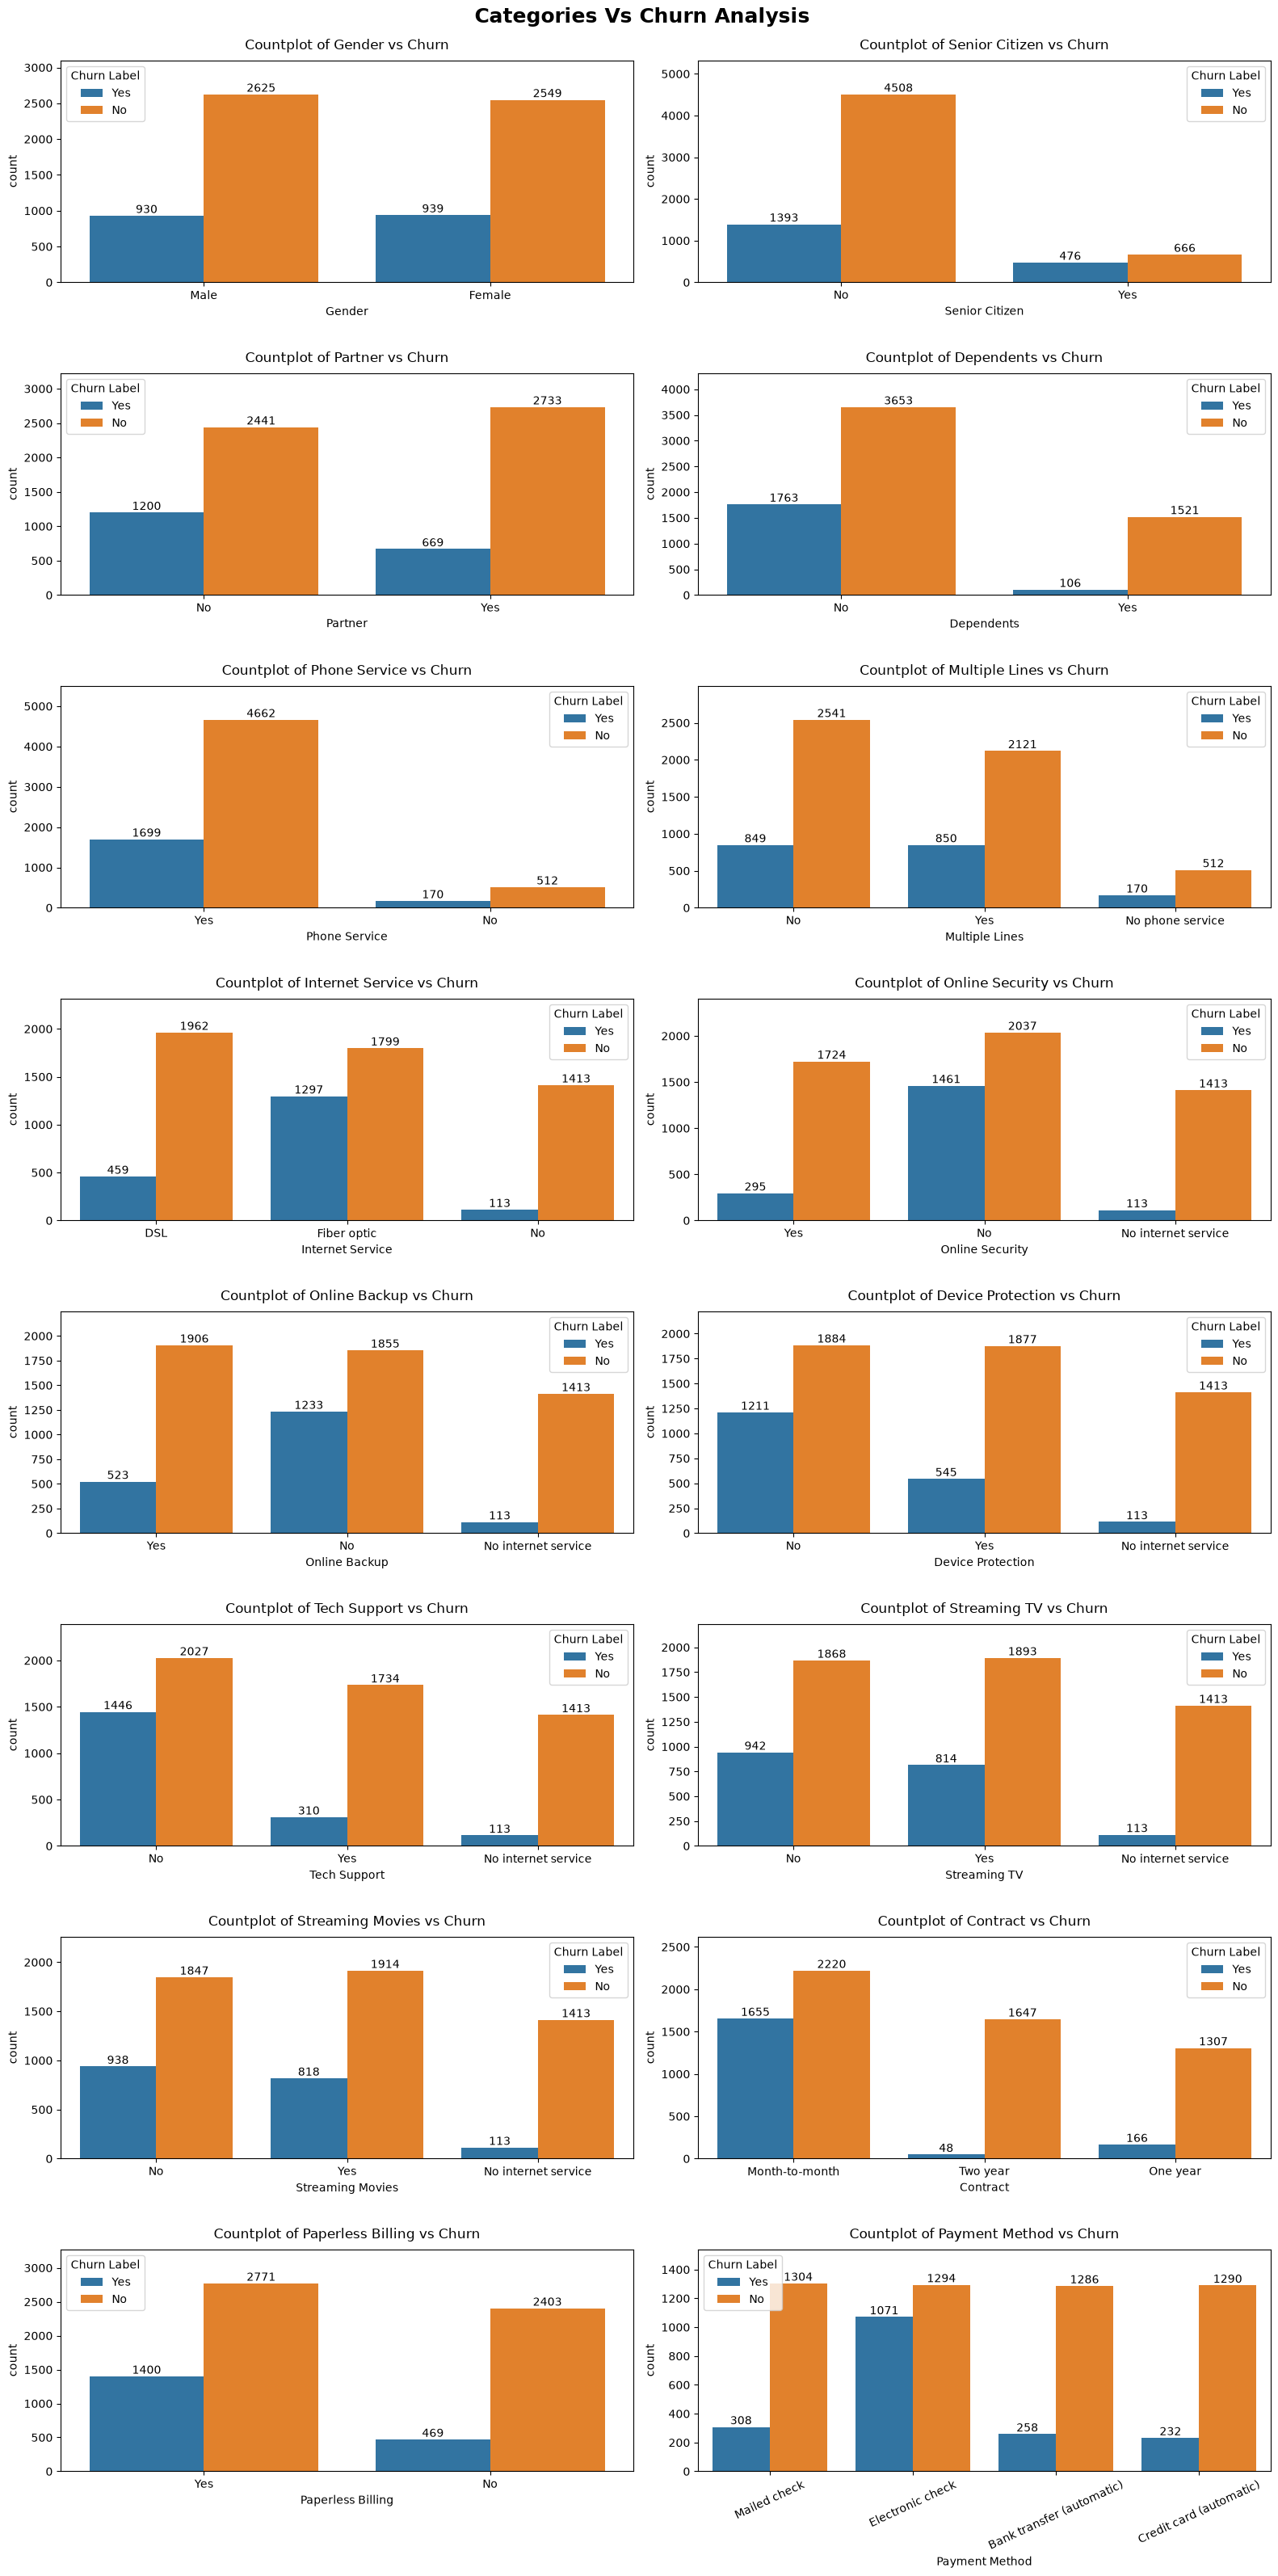

In [14]:
fig, axes = plt.subplots(8, 2, figsize=(16, 32))
plt.suptitle("Categories Vs Churn Analysis", fontsize=18, fontweight="bold", y=0.995)
ax = axes.flatten()
for i, col in enumerate(cols):
    ax[i].set_title(f"Countplot of {col} vs Churn", fontsize=12, pad=10)
    plot = sns.countplot(x=col, hue="Churn Label", data=df, ax=ax[i])
    for container in plot.containers:
        plot.bar_label(container, fontsize=10)
    ax[i].margins(y=0.18)
ax[-1].tick_params(axis='x', rotation=25)
plt.tight_layout(h_pad=3)
plt.savefig("images/categories_churn.png", dpi=600)
plt.show()

In [15]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [16]:
df.isna().sum()[df.isna().sum() > 0]

Total Charges      11
Churn Reason     5174
dtype: int64

In [17]:
new_df = df.loc[df["Total Charges"].isna()]

In [18]:
new_df["Monthly Charges"]

2234    52.55
2438    20.25
2568    80.85
2667    25.75
2856    56.05
4331    19.85
4687    25.35
5104    20.00
5719    19.70
6772    73.35
6840    61.90
Name: Monthly Charges, dtype: float64

In [19]:
new_df["Tenure Months"]

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [20]:
pass_through = ["Tenure Months", "Monthly Charges", "Total Charges"]

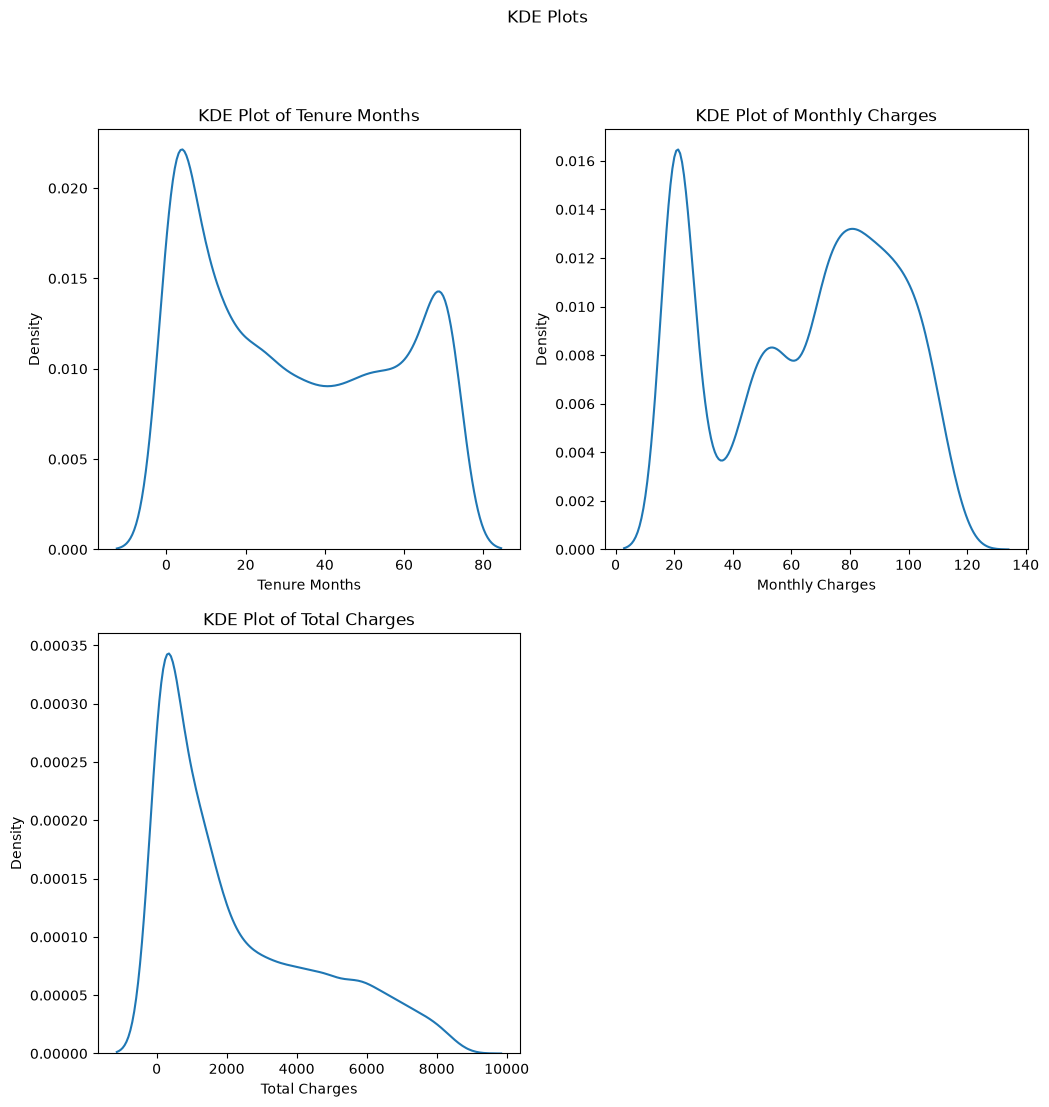

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plt.suptitle("KDE Plots")
ax = axes.flatten()
for i, col in enumerate(pass_through):
    ax[i].set_title(f"KDE Plot of {col}")
    sns.kdeplot(x=col, data=df, ax=ax[i])
ax[-1].set_visible(False)
plt.savefig("images/kdeplots.png")
plt.show()